# **Análise de Salários em Relação a Experiência e Educação**
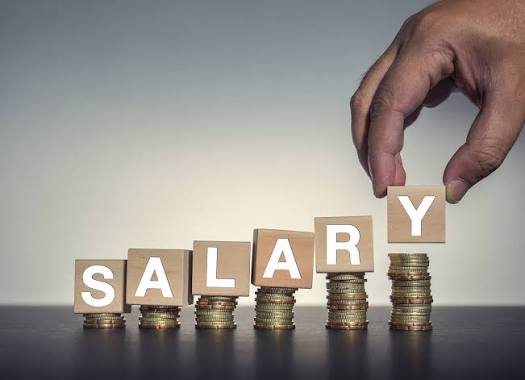

Este projeto analisa como anos de experiência e nível educacional afetam os salários usando dados de um conjunto de dados de salários.

## Objetivos
- Explorar a relação entre salário, experiência e educação
- Identificar possíveis outliers e tratá-los
- Construir modelos preditivos de salário
- Avaliar o impacto de diferentes fatores nos salários

## Métodos Utilizados
- Análise exploratória de dados
- Visualizações com ggplot2
- Modelagem linear
- Remoção de outliers usando IQR
- Função de previsão salarial

In [94]:
require(tidyverse)



In [95]:
data <- read.csv('/Salary_Data.csv')
head(data)


,Age,Gender,Education.Level,Job.Title,Years.of.Experience,Salary
,<int>,<chr>,<chr>,<chr>,<dbl>,<int>
1,32,Male,Bachelor's,Software Engineer,5,90000
2,28,Female,Master's,Data Analyst,3,65000
3,45,Male,PhD,Senior Manager,15,150000
4,36,Female,Bachelor's,Sales Associate,7,60000
5,52,Male,Master's,Director,20,200000
6,29,Male,Bachelor's,Marketing Analyst,2,55000


In [96]:
summary(data)

      Age           Gender          Education.Level     Job.Title        
 Min.   :21.00   Length:6704        Length:6704        Length:6704       
 1st Qu.:28.00   Class :character   Class :character   Class :character  
 Median :32.00   Mode  :character   Mode  :character   Mode  :character  
 Mean   :33.62                                                           
 3rd Qu.:38.00                                                           
 Max.   :62.00                                                           
 NA's   :2                                                               
 Years.of.Experience     Salary      
 Min.   : 0.000      Min.   :   350  
 1st Qu.: 3.000      1st Qu.: 70000  
 Median : 7.000      Median :115000  
 Mean   : 8.095      Mean   :115327  
 3rd Qu.:12.000      3rd Qu.:160000  
 Max.   :34.000      Max.   :250000  
 NA's   :3           NA's   :5       

In [97]:
# Remover as linhas com valores ausentes (alternativa)
data <- na.omit(data)


In [98]:
data$Gender <- as.factor(data$Gender)
data$Education.Level <- as.factor(data$Education.Level)
head(data)


,Age,Gender,Education.Level,Job.Title,Years.of.Experience,Salary
,<int>,<fct>,<fct>,<chr>,<dbl>,<int>
1,32,Male,Bachelor's,Software Engineer,5,90000
2,28,Female,Master's,Data Analyst,3,65000
3,45,Male,PhD,Senior Manager,15,150000
4,36,Female,Bachelor's,Sales Associate,7,60000
5,52,Male,Master's,Director,20,200000
6,29,Male,Bachelor's,Marketing Analyst,2,55000


In [99]:


data <- data %>%
  mutate(
    Education.Level = case_when(
      Education.Level %in% c("Bachelor's", "Bachelor's Degree") ~ "Bacharelado",
      Education.Level %in% c("Master's", "Master's Degree")     ~ "Mestrado",
      Education.Level %in% c("phD", "PhD")                      ~ "Doutorado",
      Education.Level == "High School"                          ~ "Ensino Médio",
      TRUE ~ as.character(Education.Level)
    ),
    Gender = recode(Gender,
      "Male"   = "Masculino",
      "Female" = "Feminino"
    )
  )


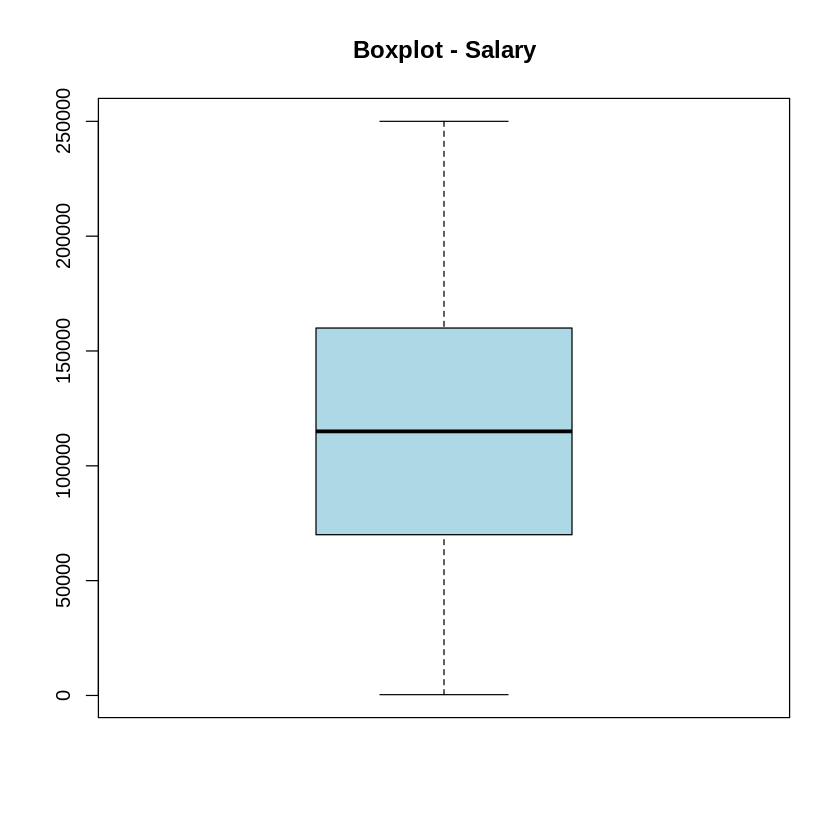

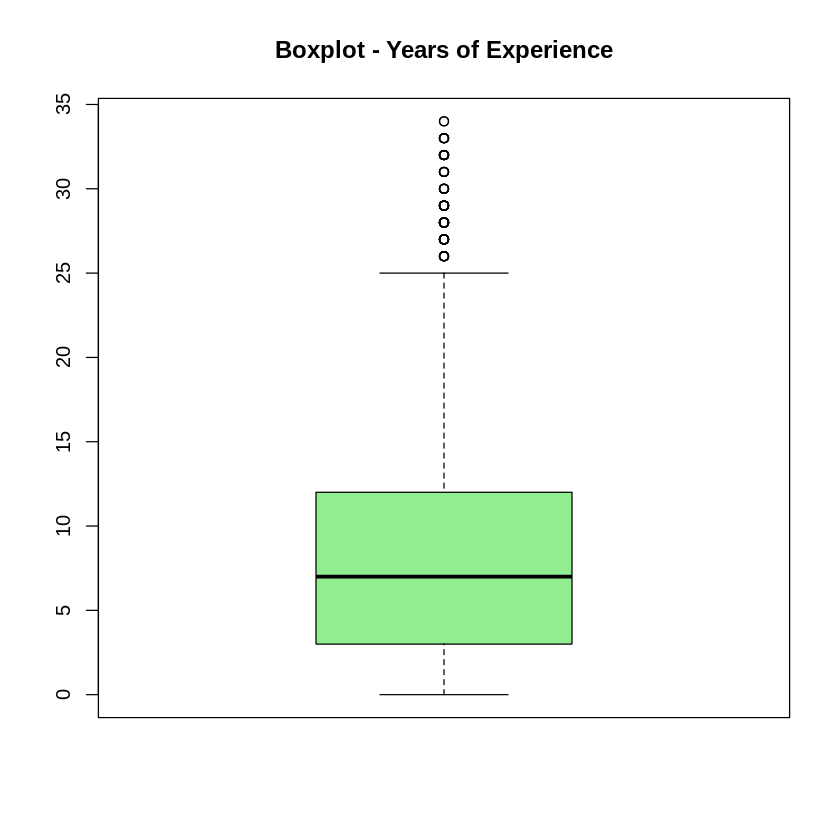

In [100]:
# Boxplot para Salary com título
boxplot(data$Salary, main = "Boxplot - Salary", col = "lightblue")

# Boxplot para Years of Experience com título
boxplot(data$Years.of.Experience, main = "Boxplot - Years of Experience", col = "lightgreen")


## 📐 Hora de remover outliers que possam atrapalhar nosso modelo.
Esta é a fórmula do IQR para remover outliers:

IQR = Q3 − Q1

Limite inferior = Q1 − 1.5 × IQR

Limite superior = Q3 + 1.5 × IQR

Filtrar os dados que estiverem dentro desse intervalo

🧮 Aplicando aos  dados:
Q1 = 3

Q3 = 12

IQR = 12 − 3 = 9

Limite inferior = 3 − 1.5 × 9 = −10.5 → arredonda para 0 (já que tempo de experiência não é negativo)

Limite superior = 12 + 1.5 × 9 = 25.5

In [101]:
#Removing outliers
data = data%>%
  filter(Years.of.Experience<=25)


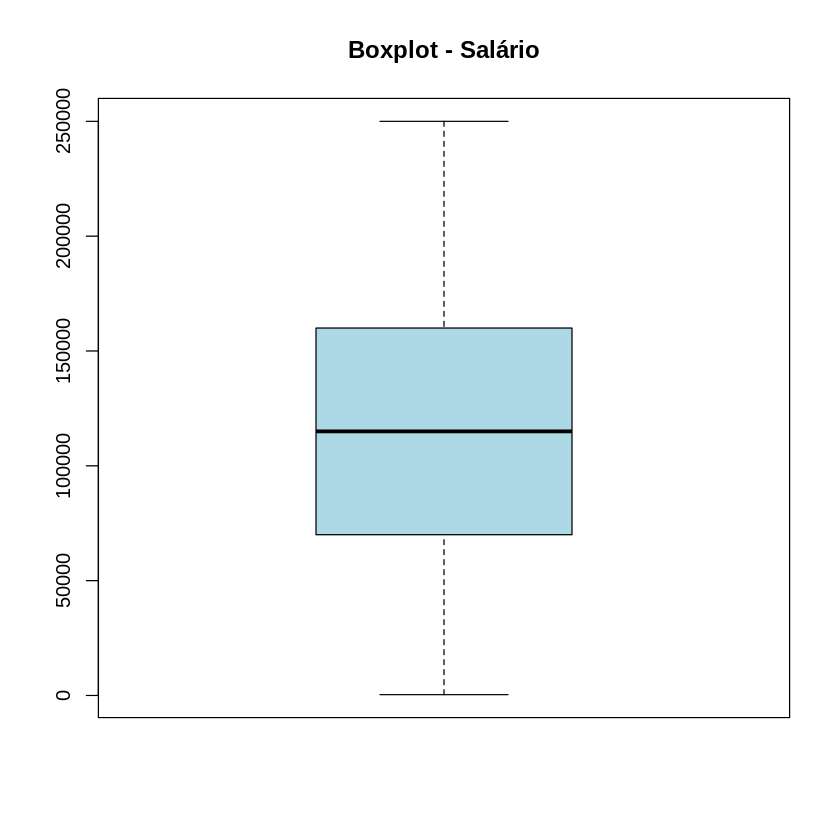

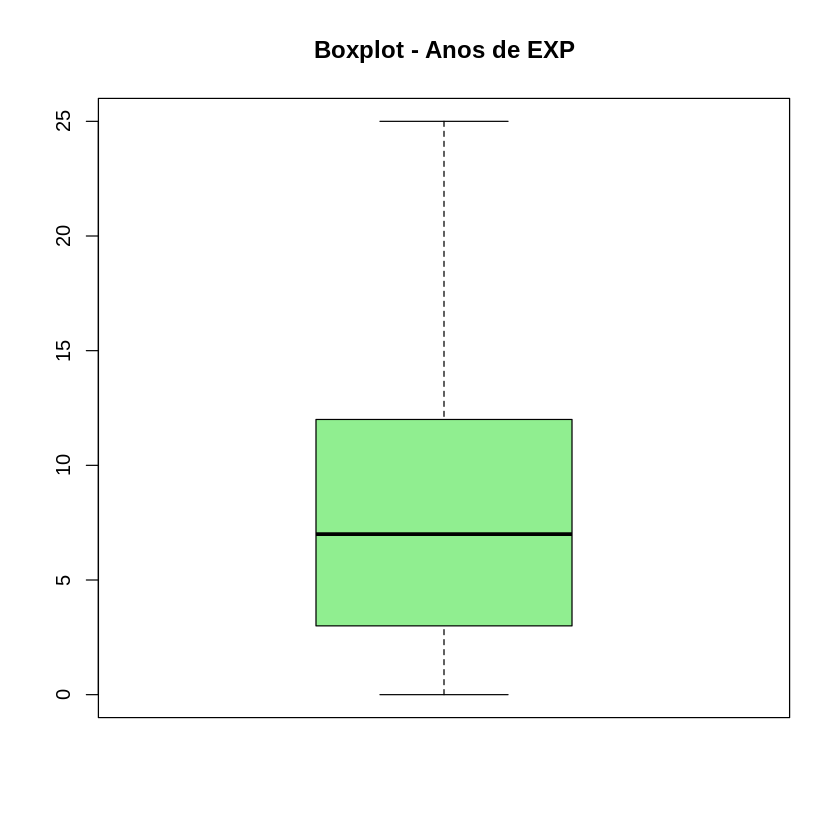

In [102]:
# Boxplot para Salary com título
boxplot(data$Salary, main = "Boxplot - Salário", col = "lightblue")

# Boxplot para Years of Experience com título
boxplot(data$Years.of.Experience, main = "Boxplot - Anos de EXP", col = "lightgreen")


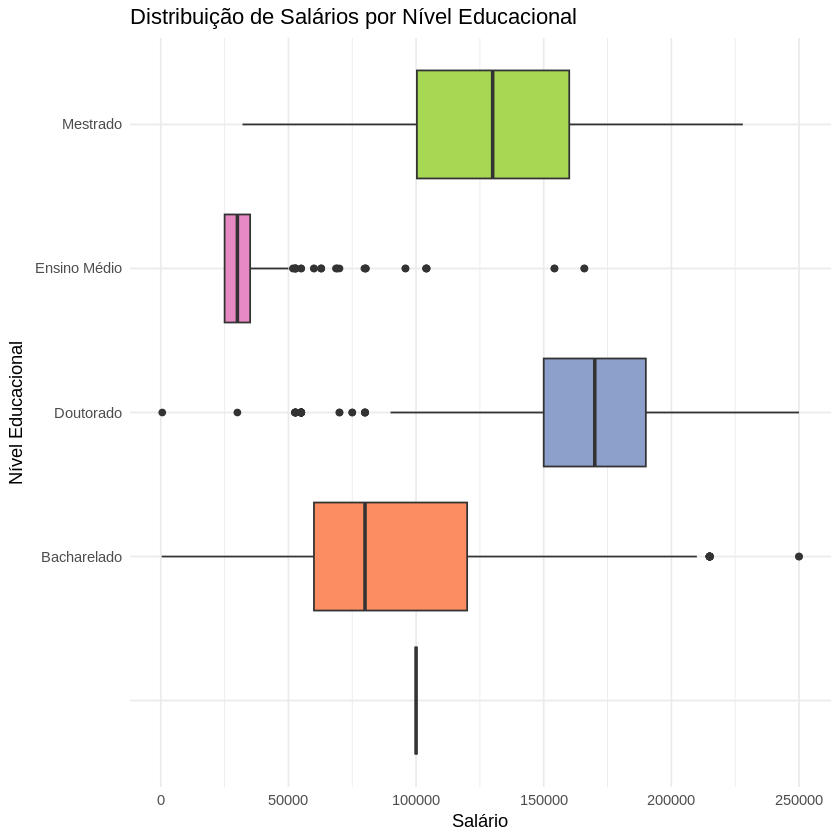

In [103]:
data %>%
  ggplot(aes(x = Education.Level, y = Salary, fill = Education.Level)) +
  geom_boxplot() +
  coord_flip() +
  labs(x = "Nível Educacional",
       y = "Salário",
       title = "Distribuição de Salários por Nível Educacional") +
  theme_minimal() +
  scale_fill_brewer(palette = "Set2") +
  theme(legend.position = "none")

## Nesses dados, gênero não parece influenciar o salário. :

`geom_smooth()` using formula = 'y ~ x'


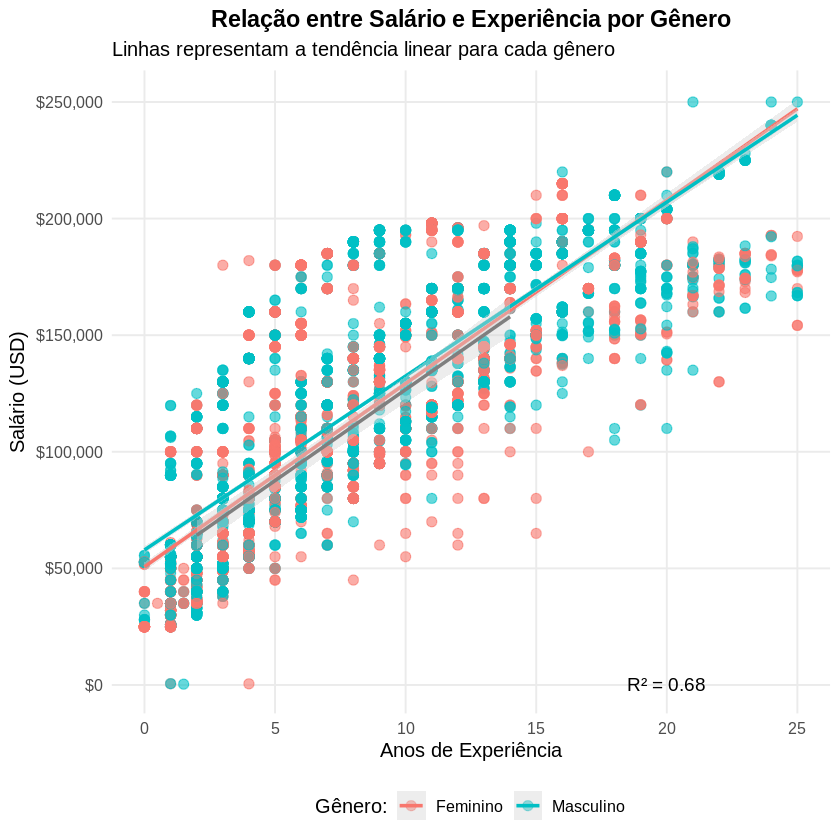

In [104]:
data %>%
  ggplot(aes(x = Years.of.Experience, y = Salary, color = Gender)) +
  geom_point(alpha = 0.6, size = 2.5) +  # Pontos mais visíveis com transparência
  geom_smooth(method = 'lm', se = TRUE, fill = "lightgray") +  # Adiciona intervalo de confiança
  scale_y_continuous(labels = scales::dollar_format()) +  # Formata eixo y como valores monetários
  scale_color_manual(values = c("Feminino" = "#F8766D", "Masculino" = "#00BFC4")) +  # Cores específicas
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(size = 14, face = "bold", hjust = 0.5),
    axis.title = element_text(size = 12),
    legend.position = "bottom",
    panel.grid.minor = element_blank()
  ) +
  labs(
    x = 'Anos de Experiência',
    y = 'Salário (USD)',
    title = 'Relação entre Salário e Experiência por Gênero',
    subtitle = 'Linhas representam a tendência linear para cada gênero',
    color = 'Gênero:'
  ) +
  annotate("text", x = max(data$Years.of.Experience)*0.8,
           y = min(data$Salary),
           label = paste("R² =", round(summary(lm(Salary ~ Years.of.Experience, data = data))$r.squared, 2)),
           color = "black", size = 4)

## Mas... e a formação acadêmica?

Vemos que influencia bastante o salário.

Indivíduos com doutourado ganham, em média, o dobro daqueles que possuem apenas o ensino médio completo.

`geom_smooth()` using formula = 'y ~ x'


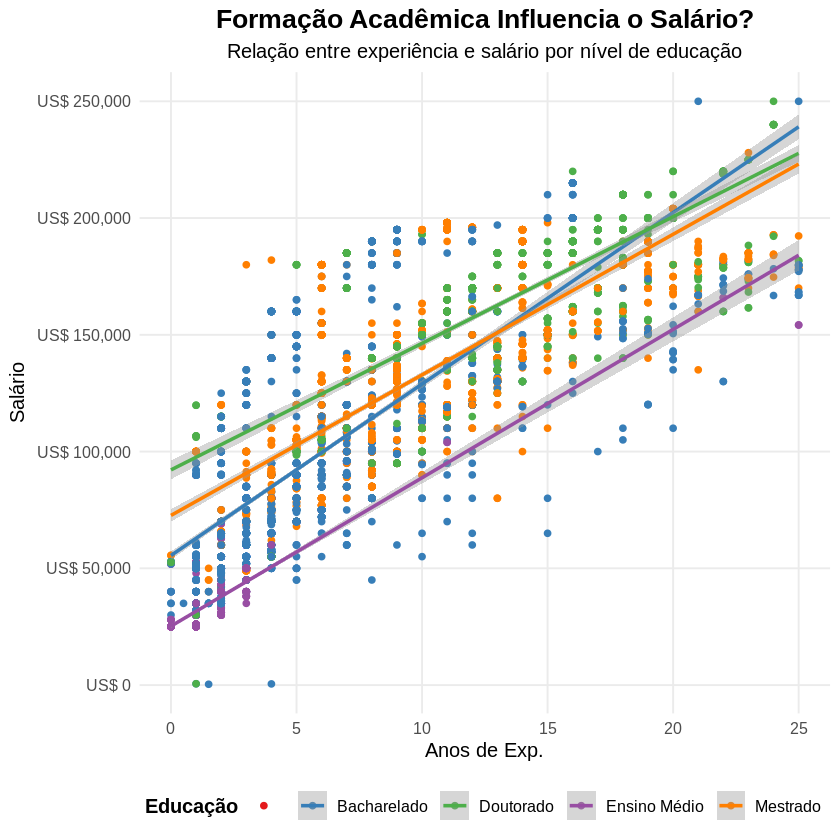

In [105]:

data%>%
  ggplot(aes(Years.of.Experience, Salary, color = Education.Level))+
  geom_point()+
  geom_smooth(method='lm')+
   theme_minimal()+
  labs(x = 'Anos de Exp.', y = 'Salário', title = 'Formação Acadêmica Influencia o Salário?', color = 'Educação', subtitle = 'Relação entre experiência e salário por nível de educação',)+
  scale_y_continuous(labels = scales::dollar_format(prefix = "US$ "))+
  theme_minimal(base_size = 12) +
  theme(
    plot.title = element_text(size = 16, face = "bold", hjust = 0.5),
    plot.subtitle = element_text(size = 12, hjust = 0.5),
    axis.title = element_text(size = 12),
    legend.title = element_text(face = "bold"),
    legend.position = "bottom",
    panel.grid.minor = element_blank(),
    plot.caption = element_text(margin = margin(t = 10))
  ) +
     scale_color_brewer(palette = "Set1")


In [106]:
lmdata= lm(Salary ~ Years.of.Experience, data = data)
summary(lmdata)


Call:
lm(formula = Salary ~ Years.of.Experience, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-104268  -22017   -5321   18393  102661 

Coefficients:
                    Estimate Std. Error t value Pr(>|t|)    
(Intercept)         54356.21     625.93   86.84   <2e-16 ***
Years.of.Experience  7660.76      64.68  118.43   <2e-16 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 29750 on 6622 degrees of freedom
Multiple R-squared:  0.6793,	Adjusted R-squared:  0.6793 
F-statistic: 1.403e+04 on 1 and 6622 DF,  p-value: < 2.2e-16


## Regressão incluindo níveis de educação.

In [107]:
lmdata= lm(Salary ~ Years.of.Experience + Education.Level, data = data)
summary(lmdata)


Call:
lm(formula = Salary ~ Years.of.Experience + Education.Level, 
    data = data)

Residuals:
   Min     1Q Median     3Q    Max 
-92013 -20203  -3756  14266  92034 

Coefficients:
                             Estimate Std. Error t value Pr(>|t|)    
(Intercept)                  54867.36   27897.82   1.967   0.0493 *  
Years.of.Experience           6447.52      77.69  82.996   <2e-16 ***
Education.LevelBacharelado    5432.95   27897.44   0.195   0.8456    
Education.LevelDoutorado     23496.10   27907.50   0.842   0.3999    
Education.LevelEnsino Médio -29770.27   27927.27  -1.066   0.2865    
Education.LevelMestrado      13755.63   27900.74   0.493   0.6220    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 27890 on 6618 degrees of freedom
Multiple R-squared:  0.7183,	Adjusted R-squared:  0.7181 
F-statistic:  3375 on 5 and 6618 DF,  p-value: < 2.2e-16


In [108]:
prever_salario <- function(anos_experiencia, nivel_educacional) {
  # Criar um data frame com os novos dados
  nova_entrada <- data.frame(
    Years.of.Experience = anos_experiencia,
    Education.Level = factor(nivel_educacional,
                             levels = levels(data$Education.Level)) # garantir que o fator tenha os mesmos níveis
  )

  # Fazer a previsão com o modelo
  previsao <- predict(lmdata, newdata = nova_entrada)
  salario_formatado <- formatC(previsao, format = "f", big.mark = ".", digits = 2, decimal.mark = ",")


  # Exibir o resultado formatado
  return(paste("O salário previsto é ", round(previsao), " dólares por ano"))
}


In [109]:
# Testando para 10 anos de experiência e nível educacional "Mestrado"
prever_salario(10, "Mestrado")


[1] "O salário previsto é  NA  dólares por ano"

A educação tem um impacto no modelo, como mostrado pelo aumento do R² quando é incluida essa variável. No entanto, os coeficientes de educação não são estatisticamente significativos (com altos valores-p), o que significa que não podemos afirmar com confiança que os diferentes níveis educacionais têm um efeito direto sobre o salário por si só.

Isso pode ser explicado pela colinearidade com a variável de experiência ou pela falta de variação significativa nos salários dentro de cada nível educacional, ou seja, pessoas com mais experiência tendem a ter mais educação (ou vice-versa), o que pode tornar mais difícil detectar um efeito independente do nível educacional no modelo.

Warning message:
“not plotting observations with leverage one:
  2010”


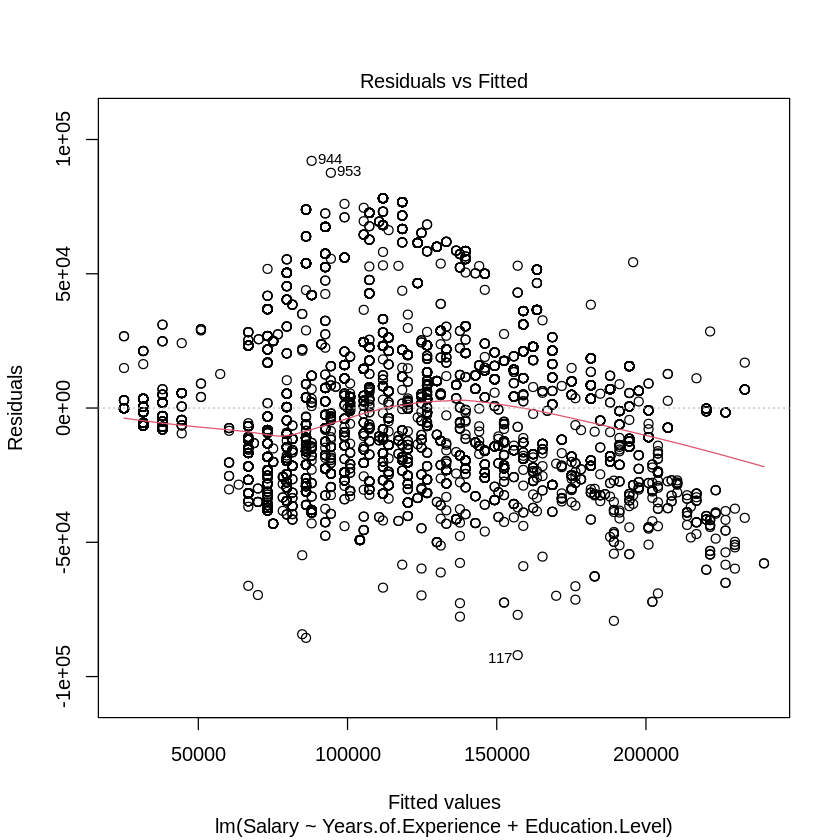

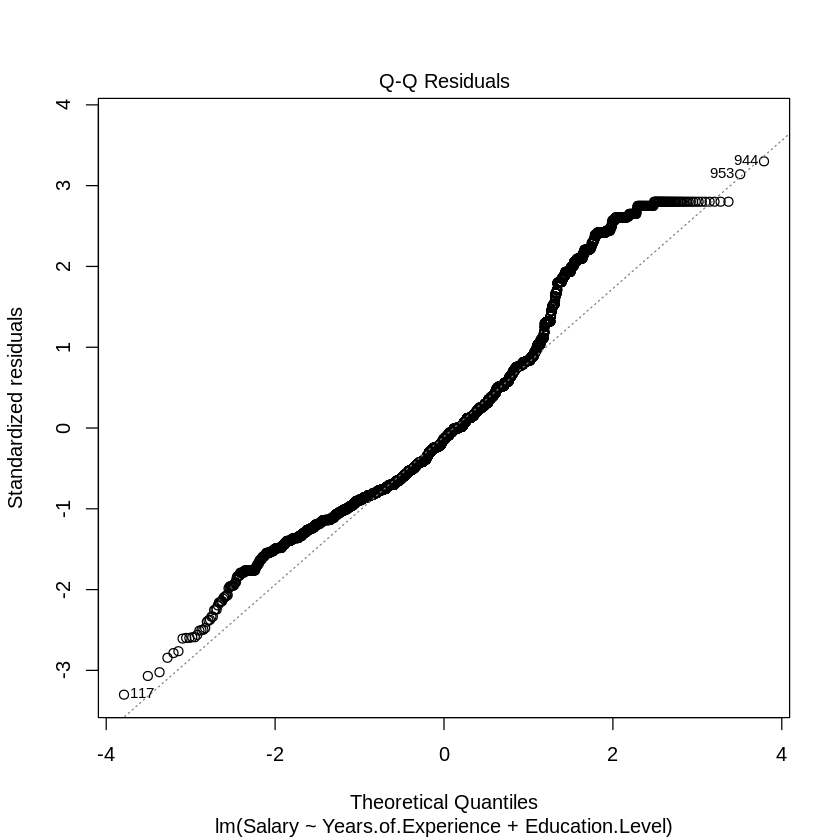

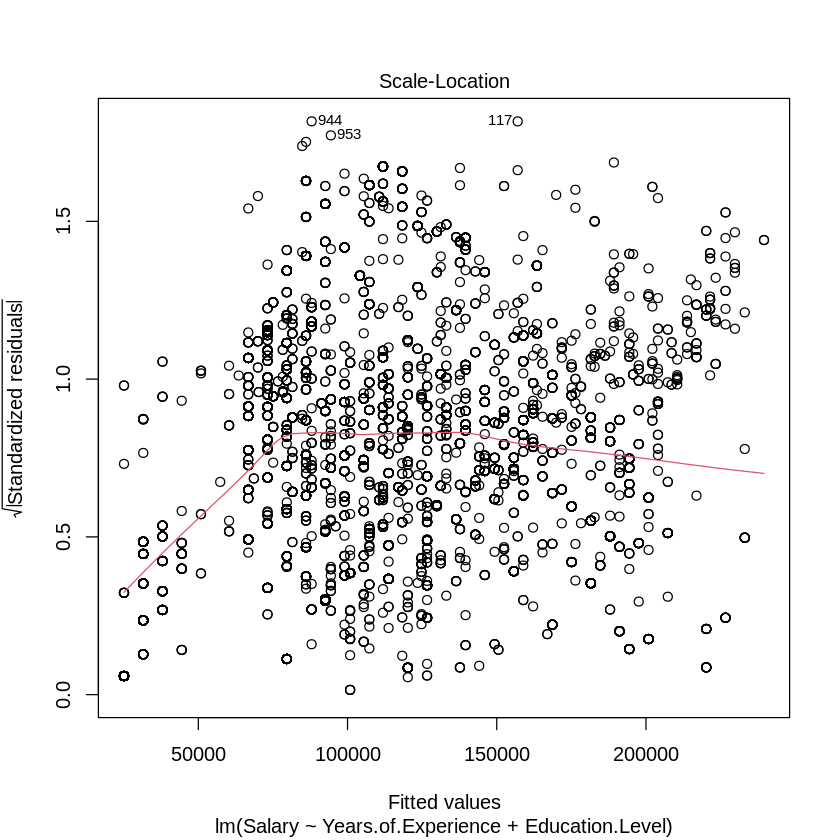

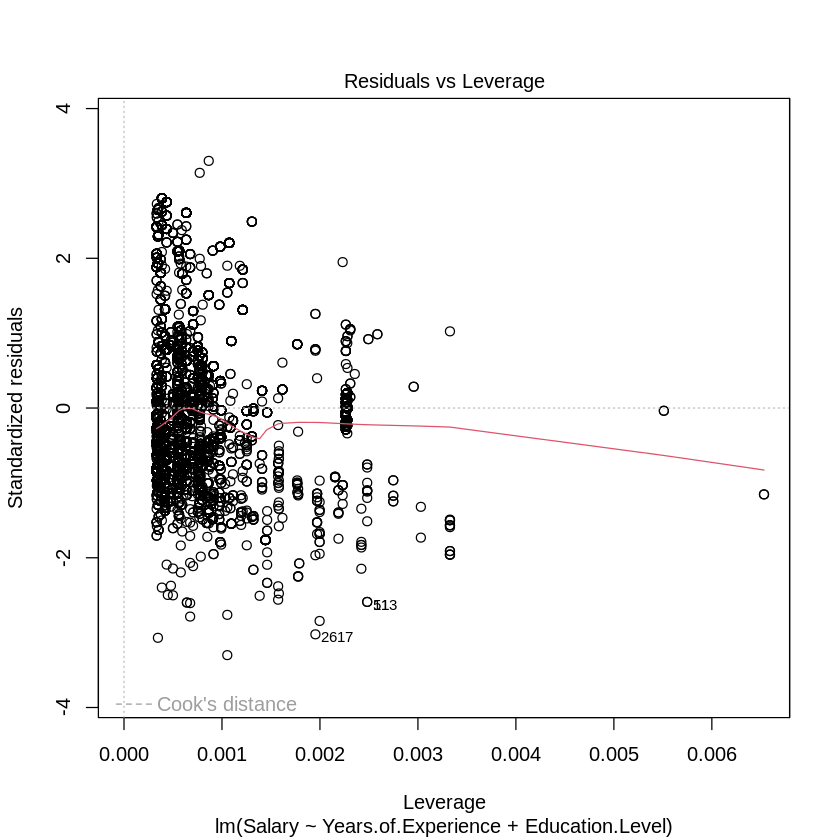

In [111]:
plot(lmdata)

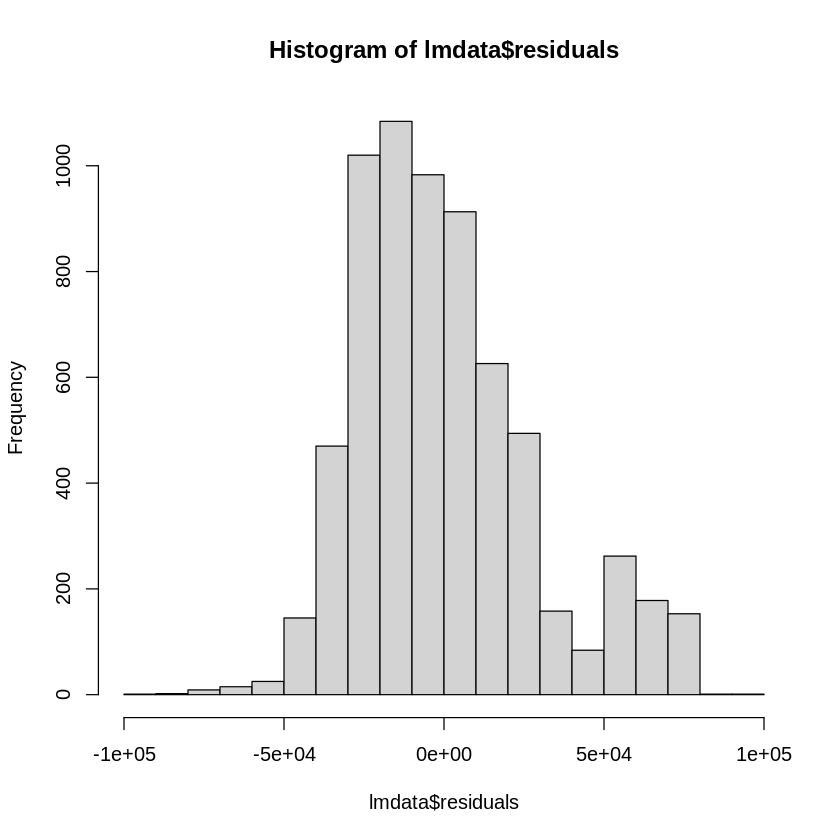

In [77]:
hist(lmdata$residuals)